In [1]:
import pandas as pd
import re

# ===================================
# DOSYALAR
# ===================================

GIRIS_DOSYASI = "temiz_laptop_yorumlari.xlsx"

CIKTI_1 = "duygu_analizi.xlsx"
CIKTI_2 = "urun_duygu_ozeti.xlsx"


# ===================================
# EXCEL OKU
# ===================================

df = pd.read_excel(GIRIS_DOSYASI)

print("Toplam yorum:", len(df))


# ===================================
# KELİME LİSTELERİ
# ===================================

pozitif_kelimeler = [
    "iyi",
    "güzel",
    "hızlı",
    "kaliteli",
    "memnun",
    "mükemmel",
    "harika",
    "başarılı",
    "yeterli",
    "tavsiye",
    "sessiz",
    "beğendim",
    "sorunsuz",
    "şık",
    "sağlam",
    "akıcı",
    "güçlü"
]

negatif_kelimeler = [
    "kötü",
    "ısınma",
    "ısınıyor",
    "fan",
    "gürültü",
    "ses",
    "donma",
    "kasma",
    "servis",
    "batarya",
    "şarj",
    "problem",
    "sorun",
    "bozuk",
    "yavaş",
    "iade",
    "eksik",
    "hasarlı",
    "çizik"
]


# ===================================
# YARDIMCI FONKSİYONLAR
# ===================================

def temizle(metin):

    if pd.isna(metin):
        return ""

    metin = str(metin).lower()
    metin = re.sub(r"\s+", " ", metin)

    return metin.strip()


def kelime_say(metin, kelime_listesi):

    toplam = 0

    for kelime in kelime_listesi:

        toplam += len(
            re.findall(
                rf"\b{re.escape(kelime)}\b",
                metin
            )
        )

    return toplam


# ===================================
# TEMİZ YORUM
# ===================================

df["yorum_temiz"] = df["yorum_metni"].apply(temizle)


# ===================================
# PUANLAR
# ===================================

df["pozitif_puan"] = df["yorum_temiz"].apply(
    lambda x: kelime_say(x, pozitif_kelimeler)
)

df["negatif_puan"] = df["yorum_temiz"].apply(
    lambda x: kelime_say(x, negatif_kelimeler)
)


# ===================================
# DUYGU SINIFLANDIRMASI
# ===================================

def duygu_belirle(row):

    pozitif = row["pozitif_puan"]
    negatif = row["negatif_puan"]

    if pozitif > negatif:
        return "Pozitif"

    elif negatif > pozitif:
        return "Negatif"

    else:
        return "Kararsız"


df["duygu"] = df.apply(
    duygu_belirle,
    axis=1
)


# ===================================
# HER YORUM İÇİN DOSYA
# ===================================

yorum_duygu = df[
    [
        "ürün_id",
        "ürün_adı",
        "yorum_metni",
        "pozitif_puan",
        "negatif_puan",
        "duygu"
    ]
]

yorum_duygu.to_excel(
    CIKTI_1,
    index=False
)

print(CIKTI_1, "oluşturuldu.")


# ===================================
# ÜRÜN BAZLI ÖZET
# ===================================

urun_duygu = df.groupby(
    ["ürün_id", "ürün_adı"]
)["duygu"].value_counts().unstack(fill_value=0)

urun_duygu = urun_duygu.reset_index()


# Eksik sütunlar varsa oluştur
for kolon in ["Pozitif", "Negatif", "Kararsız"]:

    if kolon not in urun_duygu.columns:

        urun_duygu[kolon] = 0


urun_duygu.rename(
    columns={
        "Pozitif": "pozitif_yorum_sayisi",
        "Negatif": "negatif_yorum_sayisi",
        "Kararsız": "kararsiz_yorum_sayisi"
    },
    inplace=True
)


# ===================================
# ORANLAR
# ===================================

urun_duygu["toplam_yorum"] = (
        urun_duygu["pozitif_yorum_sayisi"]
        + urun_duygu["negatif_yorum_sayisi"]
        + urun_duygu["kararsiz_yorum_sayisi"]
)


urun_duygu["pozitiflik_orani"] = (
        urun_duygu["pozitif_yorum_sayisi"]
        / urun_duygu["toplam_yorum"]
)


urun_duygu["negatiflik_orani"] = (
        urun_duygu["negatif_yorum_sayisi"]
        / urun_duygu["toplam_yorum"]
)


# ===================================
# KAYDET
# ===================================

urun_duygu.to_excel(
    CIKTI_2,
    index=False
)

print(CIKTI_2, "oluşturuldu.")

print()
print("Toplam ürün:", len(urun_duygu))

Toplam yorum: 2914
duygu_analizi.xlsx oluşturuldu.
urun_duygu_ozeti.xlsx oluşturuldu.

Toplam ürün: 269


Duygu dağılımı:
duygu
Pozitif     1909
Kararsız     738
Negatif      267
Name: count, dtype: int64


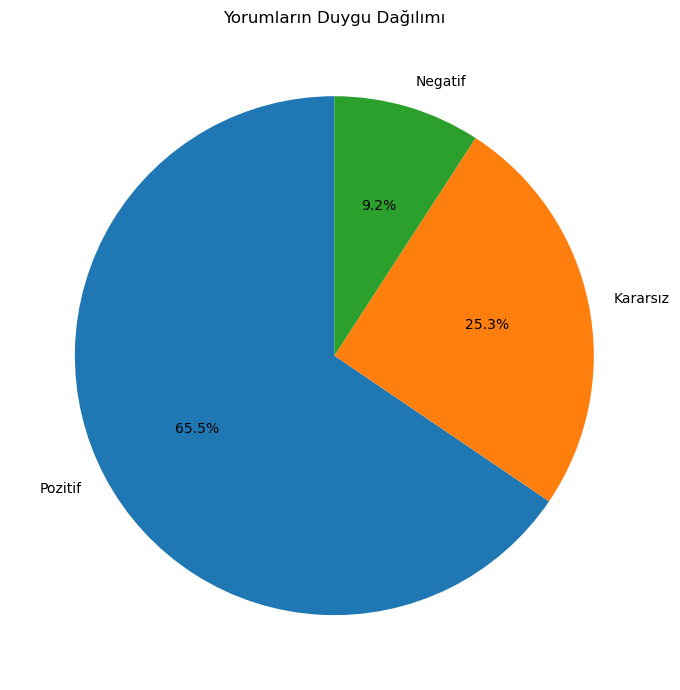

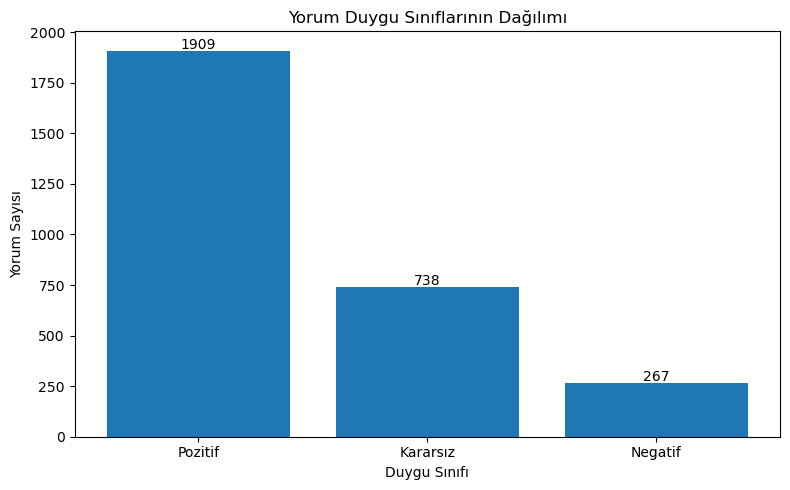

Grafikler kaydedildi:
duygu_pasta_grafigi.png
duygu_cubuk_grafigi.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "duygu_analizi.xlsx"

PASTA_GRAFIK = "duygu_pasta_grafigi.png"
CUBUK_GRAFIK = "duygu_cubuk_grafigi.png"

df = pd.read_excel(GIRIS_DOSYASI)

# ==============================
# DUYGU DAĞILIMI
# ==============================

duygu_sayilari = df["duygu"].value_counts()

print("Duygu dağılımı:")
print(duygu_sayilari)


# ==============================
# PASTA GRAFİĞİ
# ==============================

plt.figure(figsize=(7, 7))
plt.pie(
    duygu_sayilari.values,
    labels=duygu_sayilari.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Yorumların Duygu Dağılımı")
plt.tight_layout()
plt.savefig(PASTA_GRAFIK, dpi=300)
plt.show()


# ==============================
# ÇUBUK GRAFİĞİ
# ==============================

plt.figure(figsize=(8, 5))
plt.bar(
    duygu_sayilari.index,
    duygu_sayilari.values
)

plt.title("Yorum Duygu Sınıflarının Dağılımı")
plt.xlabel("Duygu Sınıfı")
plt.ylabel("Yorum Sayısı")

for i, value in enumerate(duygu_sayilari.values):
    plt.text(i, value + 10, str(value), ha="center")

plt.tight_layout()
plt.savefig(CUBUK_GRAFIK, dpi=300)
plt.show()

print("Grafikler kaydedildi:")
print(PASTA_GRAFIK)
print(CUBUK_GRAFIK)